<a href="https://colab.research.google.com/github/elijahmoon-hub/Elijah-s-repository/blob/main/ElijMoon_Unit6Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Penguins

I will be making a linear model to predict the species of penguins using multiple predictors. The variables being considered are body mass, bill length, bill depth, and flipper length. I will be predicting which factors contribute to the different attributes of Adelie, Chinstrap, and Gentoo Penguins. I find this topic interesting because penguins are very exotic creatures that aren't found naturally in the United States, only living in extremely cold climates. I want to learn more about a unique bird that can't fly and determine how binary physical attributes can destinguish species. We often times use characteristics that we can physically see such as color or height to distinguish between species, but this allows us to explore another angle.

In [2]:
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import matplotlib.pyplot as plt

In [5]:
!pip install --upgrade --quiet git+https://github.com/pydata/xarray.git
!pip install --upgrade --quiet bambi
import bambi as bmb
import seaborn as sns
import graphviz as gv

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 14.0 MB/s eta 0:00:00


#Data

In [6]:
we_data = pd.read_csv("https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/penguins.csv")
we_data.head(10) # pe_data means "Penguins data"

,species,island,bill_length,bill_depth,flipper_length,body_mass,sex,year
0,Adelie,Torgersen,3.91,1.87,18.1,3.750,male,2007
1,Adelie,Torgersen,3.95,1.74,18.6,3.800,female,2007
2,Adelie,Torgersen,4.03,1.80,19.5,3.250,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,3.67,1.93,19.3,3.450,female,2007
5,Adelie,Torgersen,3.93,2.06,19.0,3.650,male,2007
6,Adelie,Torgersen,3.89,1.78,18.1,3.625,female,2007
7,Adelie,Torgersen,3.92,1.96,19.5,4.675,male,2007
8,Adelie,Torgersen,3.41,1.81,19.3,3.475,NaN,2007
9,Adelie,Torgersen,4.20,2.02,19.0,4.250,NaN,2007


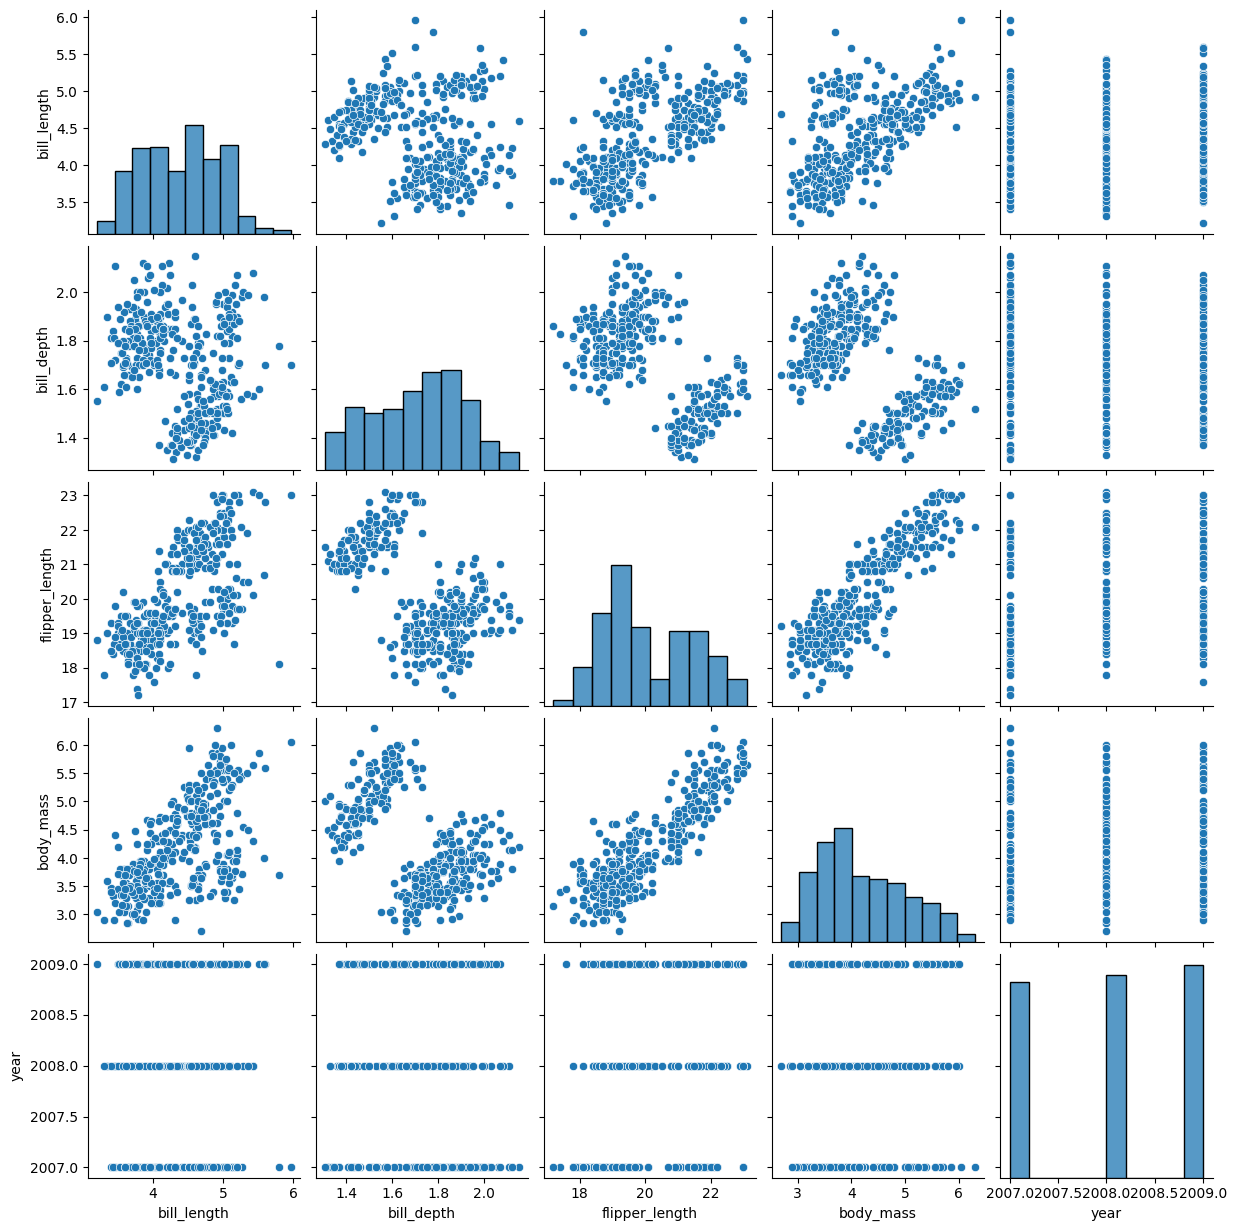

In [7]:

sns.pairplot(we_data)

I recognize a lot of linear relationships in the data, with flipper length and body mass, flipper length and bill length, and body mass and bill length having positive correlations.  

I'm using the Python library Bambi to create our multi-linear models. I will create four different combinations of the three factors and use elpd_loo to see what performs best. I'll first be comparing the interactions between all three variables(2 at a time).



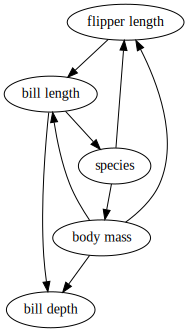

In [8]:


b_dag = gv.Digraph(name="Penguins Data")

b_dag.node('FL','flipper length')
b_dag.node('BD','bill depth')
b_dag.node('BM','body mass')
b_dag.node('BL','bill length')
b_dag.node('S', 'species')
b_dag.edges([('BM','FL'),('BM','BL'),('BL','BD'),('S','BM'),('BM','BD'),('S','FL'),('BL','S'),('FL','BL')])

b_dag

In [ ]:
import pandas as pd
import bambi as bmb
pe_data = pd.read_csv("https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/penguins.csv")
pe_data['species'] = pe_data['species'].astype('category')
pe_data.dropna(inplace=True)
#define the model
model_2 = bmb.Model("`species` ~ `bill_depth` + `body_mass` + `bill_length` + `bill_depth` : `body_mass` + `bill_depth` : `bill_length` + `body_mass` : `bill_length`", data=pe_data, family='categorical')
idata_2 = model_2.fit(draws=2000, target_accept=0.9, idata_kwargs={'log_likelihood': True})

In [ ]:
pe_data = pd.read_csv("https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/penguins.csv")
pe_data['species'] = pe_data['species'].astype('category')
pe_data.dropna(inplace=True)
#define the model
model_3 = bmb.Model("`species` ~ `bill_depth` + `body_mass` + `bill_length`", data=pe_data, family='categorical')

idata_3 = model_3.fit(draws=2000, target_accept=0.9, idata_kwargs={'log_likelihood': True})

In [ ]:
we_data = pd.read_csv("https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/penguins.csv")
we_data['species'] = we_data['species'].astype('category')
we_data.dropna(inplace=True)
#define the model
model_4 = bmb.Model("`species` ~ `flipper_length` + `body_mass` + `bill_depth`", data=we_data, family='categorical')
#fit the model
idata_4 = model_4.fit(draws=2000, target_accept=0.9, idata_kwargs={'log_likelihood': True})

In [ ]:
we_data = pd.read_csv("https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/penguins.csv")
we_data['species'] = we_data['species'].astype('category')
we_data.dropna(inplace=True)
#define the model
model_5 = bmb.Model("`species` ~ `bill_depth` + `body_mass` + `bill_length` + `body_mass` : `bill_length`", data=we_data, family='categorical')
idata_5 = model_5.fit(draws=2000, target_accept=0.9, idata_kwargs={'log_likelihood': True})

(<Figure size 1100x1300 with 1 Axes>,
 array([<Axes: xlabel='bill_length', ylabel='species'>], dtype=object))

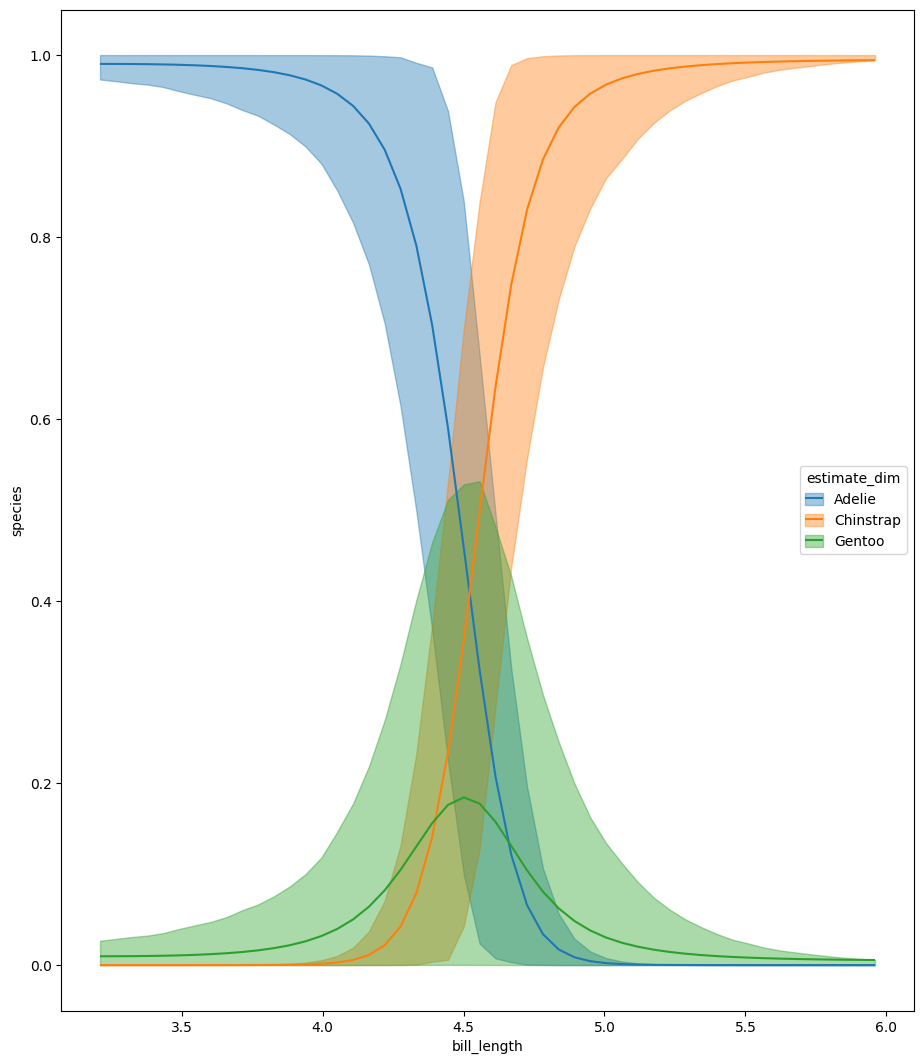

In [13]:
bmb.interpret.plot_predictions(model_2,
                               idata_2,
                               ["bill_length"],
                               fig_kwargs={"figsize":(11, 13)})#,
                               #legend=False)

Bill length often varies between species. Birds have different bill lengths based on different climates and the food they have to eat. I think that bill length would be a good predictor between different species as different diets and temperatures require different bill sizes.

(<Figure size 1100x1300 with 1 Axes>,
 array([<Axes: xlabel='bill_length', ylabel='species'>], dtype=object))

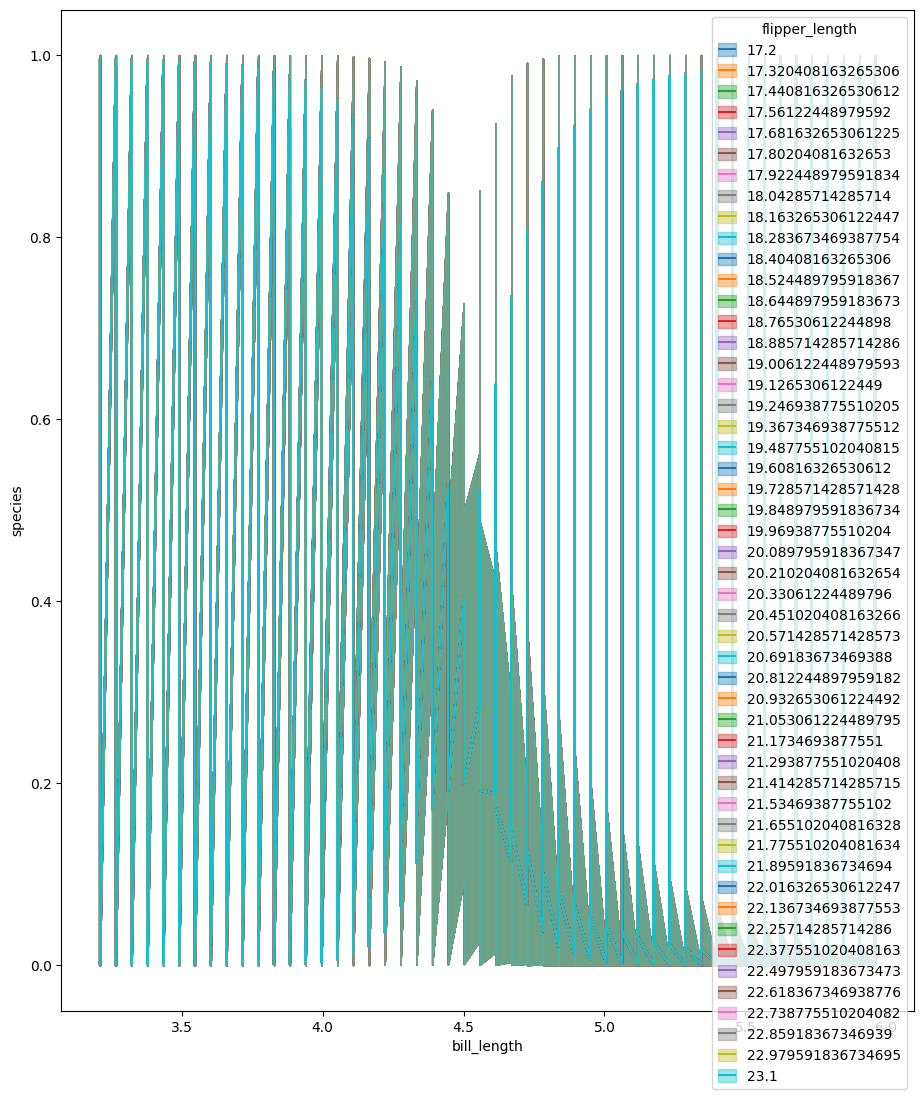

In [39]:
bmb.interpret.plot_predictions(model_3,
                               idata_3,
                               ["bill_length","flipper_length"],
                               fig_kwargs={"figsize":(11, 13)})#,
                               #legend=False)

Based on my casual deigram and pairplot, body mass is a very good predictor to determine the bill length, flipper length, and species.

(<Figure size 1100x1300 with 1 Axes>,
 array([<Axes: xlabel='body_mass', ylabel='species'>], dtype=object))

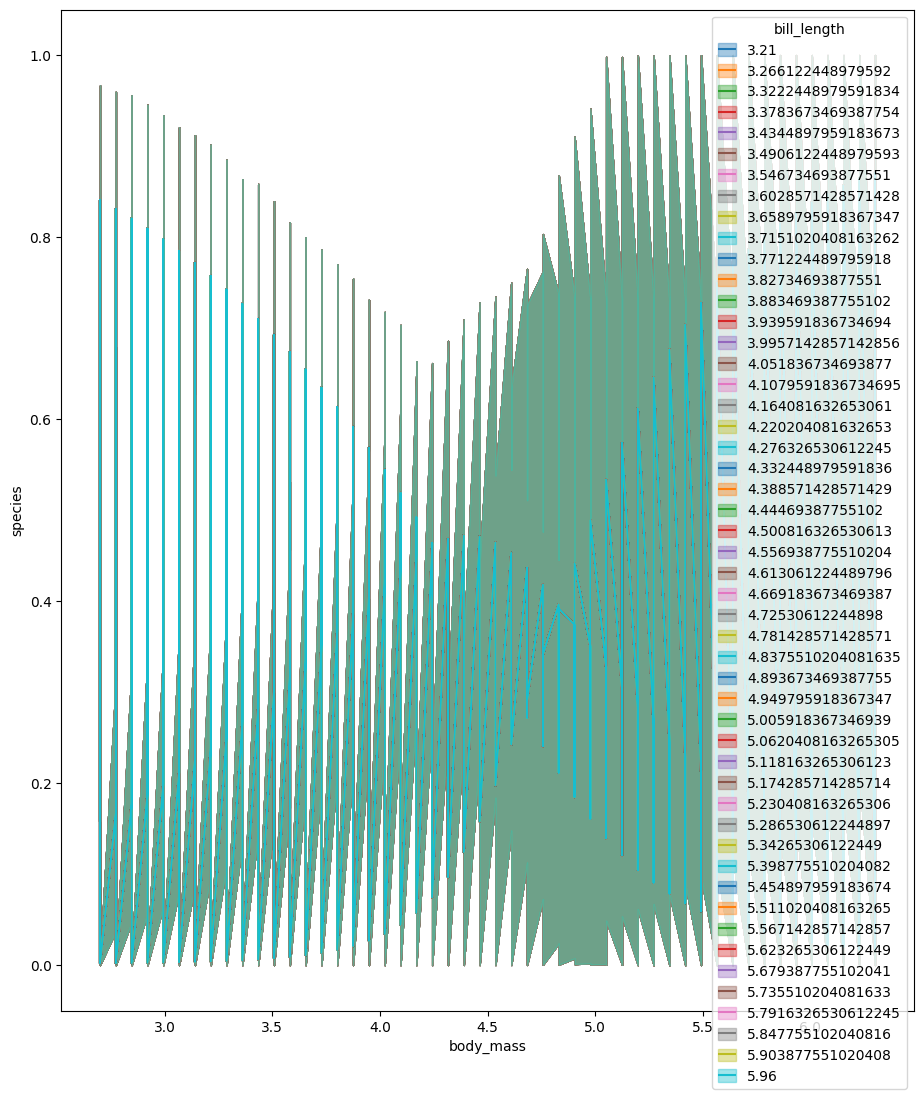

In [46]:
 bmb.interpret.plot_predictions(model_4,
                               idata_4,
                               ["body_mass","bill_length"],
                               fig_kwargs={"figsize":(11, 13)})#,
                               #legend=False)

(<Figure size 1100x1300 with 1 Axes>,
 array([<Axes: xlabel='body_mass', ylabel='species'>], dtype=object))

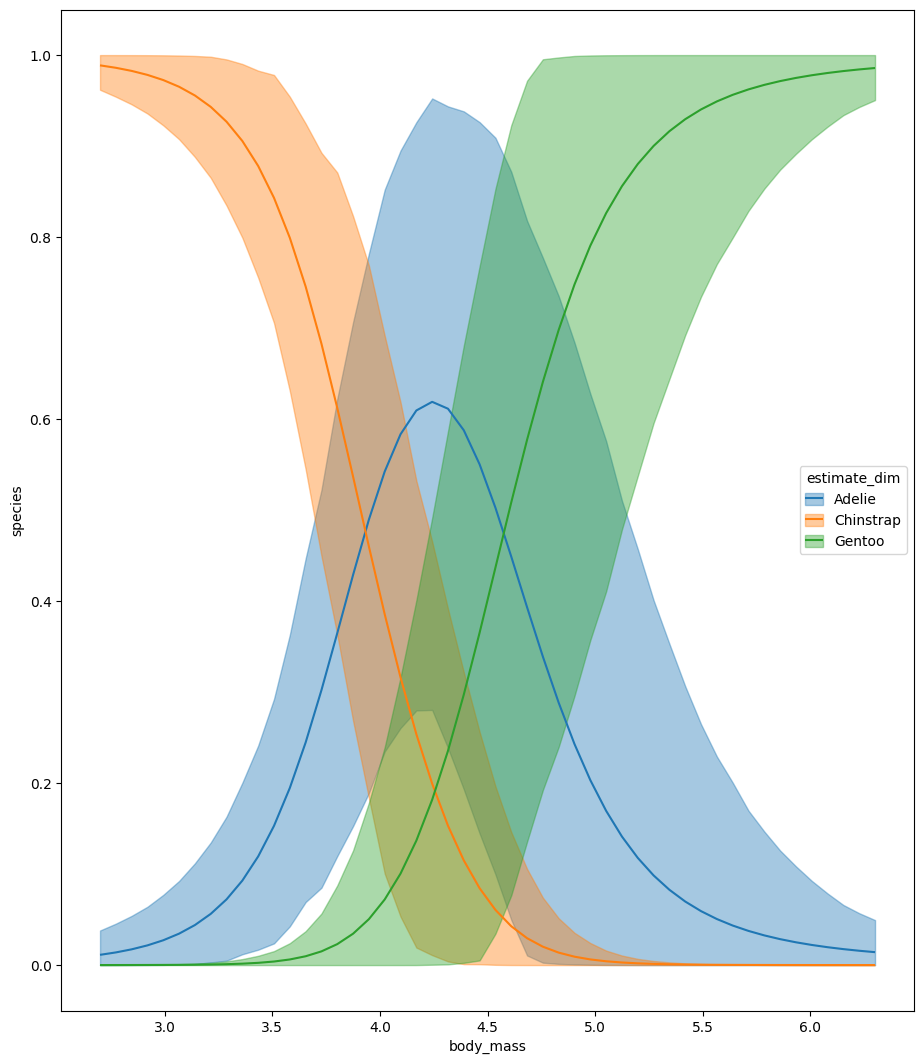

In [16]:
bmb.interpret.plot_predictions(model_5,
                               idata_5,
                               ["body_mass"],
                               fig_kwargs={"figsize":(11, 13)})#,
                               #legend=False)

This model represents body mass on the x-axis and estimates the trend as body mass increases for Adelie, Chinstrap, and Gentoo penguins portrayed by different colors. I created this model to isolate the body mass to determine how good of a predictor it is for the species, as this is helpful for most species. However, This representation wasn't very helpful for me as the trends and HDI are overalapping and not clear.

In [40]:
cmp = az.compare({"model_2": idata_2, "model_3": idata_3, "model_4": idata_4, "model_5": idata_5})
print(cmp)

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimat

         rank   elpd_loo     p_loo  elpd_diff        weight        se  \
model_2     0 -11.368404  1.673048   0.000000  1.000000e+00  2.363075   
model_5     1 -12.105830  1.449966   0.737426  8.021361e-15  2.301275   
model_3     2 -12.186509  1.326841   0.818106  1.741662e-15  2.282802   
model_4     3 -15.644135  1.424481   4.275731  0.000000e+00  2.563474   

              dse  warning scale  
model_2  0.000000     True   log  
model_5  0.316616     True   log  
model_3  0.263779     True   log  
model_4  0.617696     True   log  


/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

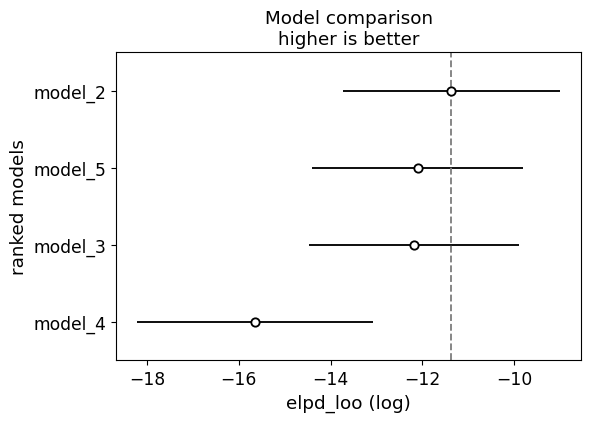

In [47]:
az.plot_compare(cmp)

Based on the elpd_loo, it seems that model_4 was very inaccurate. Model_3 and model_5  are very similar to eachother and perfromed very well. However, Model 2 was my best predictive model and was the best predictor for determining the species of penguin. Model_2 was determined by the bill length, which makes sense because birds beaks are often signifacntly different across various species due to different climate, environment, and method for collecting food.